In [1]:
import numpy as np
import pandas as pd
import re
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import collections
import itertools
import seaborn as sns
import tweepy
import datetime
import nltk
from nltk.corpus import stopwords
from afinn import Afinn
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import RegexpTokenizer
import operator
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from networkx.drawing.nx_agraph import graphviz_layout

In [2]:
df = pd.read_excel('C:/Users/jwan0/Youtubecrawl_JP_1108.xlsx', sheet_name='data')

df.head()

,Unnamed: 0,Unnamed: 0.1,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment
0,0,0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"['love', 'japan', 'italy']",love japan italy,love japan italy,love japan italy,True,0.000,0.323,0.677,0.6369,positive
1,1,1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"['0', '01', 'tokyo', 'skytre0', '02', 'tokyo',...",tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,True,0.045,0.833,0.122,0.7506,positive
2,2,2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"['japan', 'wonder', 'love', 'india']",japan wonder love india,japan wonder love india,japan wonder love india,True,0.000,0.417,0.583,0.6369,positive
3,3,3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"['currently', 'learning', 'japanese', 'see', '...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,True,0.000,0.792,0.208,0.6369,positive
4,4,4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"['watching', 'video', 'makes', 'feel', 'happy'...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,True,0.000,0.442,0.558,0.9918,positive


In [3]:
df = df.astype('string')
df.dtypes

Unnamed: 0             string
Unnamed: 0.1           string
id                     string
content of comments    string
Translation            string
text_token             string
text_string            string
text_string_fdist      string
text_string_lem        string
is_equal               string
neg                    string
neu                    string
pos                    string
compound               string
sentiment              string
dtype: object

In [4]:
import texthero as hero
from texthero import preprocessing
custom_pipeline = [preprocessing.fillna,
                   #preprocessing.lowercase,
                   preprocessing.remove_whitespace,
                   preprocessing.remove_diacritics
                   #preprocessing.remove_brackets
                  ]
df['clean_text'] = hero.clean(df['Translation'], custom_pipeline)
df['clean_text'] = [n.replace('{','') for n in df['clean_text']]
df['clean_text'] = [n.replace('}','') for n in df['clean_text']]
df['clean_text'] = [n.replace('(','') for n in df['clean_text']]
df['clean_text'] = [n.replace(')','') for n in df['clean_text']]

df.head()

,Unnamed: 0,Unnamed: 0.1,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment,clean_text
0,0,0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"['love', 'japan', 'italy']",love japan italy,love japan italy,love japan italy,True,0.0,0.323,0.677,0.6369,positive,love japan! from italy
1,1,1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"['0', '01', 'tokyo', 'skytre0', '02', 'tokyo',...",tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,True,0.045,0.833,0.122,0.7506,positive,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...
2,2,2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"['japan', 'wonder', 'love', 'india']",japan wonder love india,japan wonder love india,japan wonder love india,True,0.0,0.417,0.583,0.6369,positive,japan is such a wonder to me. love from india!
3,3,3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"['currently', 'learning', 'japanese', 'see', '...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,True,0.0,0.792,0.208,0.6369,positive,i'm currently learning japanese and when i see...
4,4,4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"['watching', 'video', 'makes', 'feel', 'happy'...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,True,0.0,0.442,0.558,0.9918,positive,watching this video makes me feel happy to be ...


In [140]:
from sklearn.feature_extraction.text import TfidfVectorizer

v = TfidfVectorizer()
x = v.fit_transform(df['clean_text'])
print(x.toarray())

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [141]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
#tokenize and tag the card text
df_docs = [TaggedDocument(doc.split(' '), [i]) 
             for i, doc in enumerate(df.clean_text)]
#display the tagged docs
df_docs

[TaggedDocument(words=["i'm", 'not', 'sure', 'how', 'any', 'other', "country's", 'tourism', 'board', 'is', 'going', 'to', 'beat', 'that'], tags=[0]),
 TaggedDocument(words=['the', 'grand', 'tour', 'is', 'only', 'a', 'fraction', 'of', 'what', 'switzerland', 'has', 'to', 'offer', 'in', 'terms', 'of', 'scenic', 'beauty.', 'it', 'is', 'a', "hiker's", 'paradise,', 'it', 'has', 'the', 'most', 'beautiful', 'mountains,', 'the', 'cleanest', 'lakes', 'and', 'the', 'most', 'beautiful', 'valleys.', 'for', 'me,', 'switzerland', 'is', 'a', 'paradise', 'on', 'earth', 'and', 'has', 'many', 'pearls', 'to', 'find.', 'when', 'you', 'travel', 'to', 'switzerland,', 'you', 'should', 'take', 'time', 'to', 'see', 'all', 'these', 'treasures.', 'it', 'is', 'worth', 'it.'], tags=[1]),
 TaggedDocument(words=['the', 'paradox', 'of', 'acting:anne', 'hathaway', 'nailing', 'every', 'beat', 'of', 'the', 'performance-', 'fakeroger', 'federer', 'barely', 'containing', 'his', 'giggles-', 'authentic'], tags=[2]),
 TaggedD

In [142]:
model = Doc2Vec(vector_size=64, min_count=1, epochs = 20)

In [143]:
#instantiate model
model = Doc2Vec(vector_size=64, window=2, min_count=1, workers=8, epochs = 40)
#build vocab
model.build_vocab(df_docs)
#train model
model.train(df_docs, total_examples=model.corpus_count
            , epochs=model.epochs)

In [148]:
#generate vectors
df2vec = [model.infer_vector((df['clean_text'][i].split(' '))) 
            for i in range(0,len(df['clean_text']))]
df2vec

[array([-0.00418852, -0.02392103,  0.18864216, -0.4116177 ,  0.44767484,
        -0.23279178,  0.36735314, -0.0657758 , -0.10001088, -0.03724843,
        -0.20874958,  0.39147222, -0.02719104, -0.16020533,  0.06300215,
         0.19217049, -0.14393288,  0.21030347, -0.09448364,  0.23249967,
         0.24108656,  0.30619374,  0.10669836, -0.19616139, -0.16948098,
        -0.28797024,  0.27011642,  0.06170305,  0.1693082 , -0.3041066 ,
         0.27889317, -0.3227017 ,  0.15354687, -0.21418764, -0.20108825,
         0.2978156 ,  0.17052849, -0.36708957, -0.3373868 ,  0.18353483,
         0.12589785, -0.37207684,  0.03447746,  0.13995358,  0.09009004,
         0.10778051,  0.01471192,  0.08082382,  0.13626443, -0.0051559 ,
        -0.17096668,  0.11485723, -0.00651315,  0.17972267, -0.1956828 ,
         0.24332298, -0.0144392 , -0.29319206,  0.04109131, -0.08943659,
        -0.0213927 , -0.09285238, -0.13014467, -0.5131655 ], dtype=float32),
 array([-0.02667963, -0.05589549,  0.3781048 , 

In [149]:
import numpy as np
#Create a list of lists
dtv= np.array(df2vec).tolist()
#set list to dataframe column
df['df2vec'] = dtv
df.head()

,Unnamed: 0,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment,clean_text,df2vec
0,1,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...,"['sure', 'country', 'tourism', 'board', 'going...",sure country tourism board going beat,sure country tourism board going beat,sure country tourism board going beat,True,0.0,0.685,0.315,0.3182,positive,i'm not sure how any other country's tourism b...,"[-0.004188515245914459, -0.023921027779579163,..."
1,2,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...,"['grand', 'tour', 'fraction', 'switzerland', '...",grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...,True,0.0,0.431,0.569,0.9812,positive,the grand tour is only a fraction of what swit...,"[-0.0266796313226223, -0.05589548870921135, 0...."
2,3,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting:anne hathaway nailing ev...,"['paradox', 'acting', 'anne', 'hathaway', 'nai...",paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...,True,0.094,0.804,0.102,0.0314,positive,the paradox of acting:anne hathaway nailing ev...,"[-0.010747785679996014, -0.05051420256495476, ..."
3,4,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...,"['anne', 'phenomenon', 'everything', 'love']",anne phenomenon everything love,anne phenomenon everything love,anne phenomenon everything love,True,0.0,0.417,0.583,0.6369,positive,anne is just phenomenon in everything. i love ...,"[-0.014323696494102478, -0.023541053757071495,..."
4,5,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,...","['federer', 'verge', 'laughing', 'lines', 'fun...",federer verge laughing lines funny thing,federer verge laughing lines funny thing,federer verge laughing lines funny thing,True,0.0,0.396,0.604,0.7269,positive,"federer on the verge of laughing to his lines,...","[-0.006636082194745541, -0.025265095755457878,..."


In [150]:
df['tsnec2v'] = hero.tsne(df['df2vec'])

In [23]:
hero.scatterplot(df, col='tsnec2v', color='convertedManaCost'
                 , title="Doc2Vec", hover_data = ['name','text'])

ValueError: Value of 'hover_data_0' is not the name of a column in 'data_frame'. Expected one of ['Unnamed: 0', 'id', 'content of comments', 'Translation', 'text_token', 'text_string', 'text_string_fdist', 'text_string_lem', 'is_equal', 'neg', 'neu', 'pos', 'compound', 'sentiment', 'clean_text', 'df2vec', 'tsnec2v'] but received: name

In [14]:
hero.scatterplot(df, col='tsnec2v',title="Doc2Vec", hover_data = ['clean_text'])

KeyError: 'tsnec2v'

In [5]:
translated_text = df['Translation']
translated_text.reset_index(inplace=True, drop=True) # 인덱스 초기화

In [15]:
tokenizer = RegexpTokenizer('[\w]+')
stop_words = stopwords.words('english')+['49','37']

count = {} # 동시출현 빈도가 저장될 dict
for line in translated_text:
    words = line
    tokens = tokenizer.tokenize(words) # 각 리뷰를 토큰화한 뒤 리스트에 저장
    stopped_tokens = [i for i in list(set(tokens)) if not i in stop_words+["br"]]
    stopped_tokens2 = [i for i in stopped_tokens if len(i)>1]
    for i,a in enumerate(stopped_tokens2):
        for b in stopped_tokens2[i+1:]:
            if a>b:
                count[b,a] = count.get((b,a),0) + 1
            else:
                count[a,b] = count.get((a,b),0) + 1
                
df1 = pd.DataFrame.from_dict(count, orient='index')

list1=[]
for i in range(len(df)):
    list1.append([df1.index[i][0], df1.index[i][1], df1[0][i]])

df2 = pd.DataFrame(list1, columns=['term1','term2','freq'])
df3 = df2.sort_values(by=['freq'], ascending=False) # freq 기준으로 내림차순 정렬
df3_nw = df3.reset_index(drop=True)

In [18]:
YT_jp_nw = nx.Graph()

# 동시출현 빈도가 10 이상인 단어들에 대해서만 중심성 계수 계산
for i in range((len(np.where(df3_nw['freq']>1)[0]))):
    YT_jp_nw.add_edge(df3_nw['term1'][i], df3_nw['term2'][i],
                  weight=int(df3_nw['freq'][i]))

dgr = nx.degree_centrality(YT_jp_nw) # 연결 중심성
btw = nx.betweenness_centrality(YT_jp_nw) # 매개 중심성
cls = nx.closeness_centrality(YT_jp_nw) # 근접 중심성
egv = nx.eigenvector_centrality(YT_jp_nw) # 고유벡터 중심성

sorted_dgr = sorted(dgr.items(), key=operator.itemgetter(1), reverse=True)
sorted_btw = sorted(btw.items(), key=operator.itemgetter(1), reverse=True)
sorted_cls = sorted(cls.items(), key=operator.itemgetter(1), reverse=True)
sorted_egv = sorted(egv.items(), key=operator.itemgetter(1), reverse=True)

print("** degree **")
for x in range(10):
    print(sorted_dgr[x])

print("** betweenness **")
for x in range(10):
    print(sorted_btw[x])
    
print("** closeness **")
for x in range(10):
    print(sorted_cls[x])

print("** eigenvector **")
for x in range(10):
    print(sorted_egv[x])

** degree **
('japan', 0.5555555555555556)
('zen', 0.4444444444444444)
('love', 0.2222222222222222)
('italy', 0.2222222222222222)
('science', 0.2222222222222222)
('japanese', 0.2222222222222222)
('national', 0.2222222222222222)
('know', 0.1111111111111111)
('sorry', 0.1111111111111111)
('come', 0.1111111111111111)
** betweenness **
('japan', 0.736111111111111)
('zen', 0.5833333333333333)
('science', 0.09722222222222221)
('national', 0.09722222222222221)
('japanese', 0.013888888888888888)
('love', 0.0)
('italy', 0.0)
('know', 0.0)
('sorry', 0.0)
('come', 0.0)
** closeness **
('japan', 0.6923076923076923)
('zen', 0.6)
('science', 0.47368421052631576)
('national', 0.47368421052631576)
('love', 0.45)
('italy', 0.45)
('know', 0.391304347826087)
('sorry', 0.391304347826087)
('come', 0.391304347826087)
('japanese', 0.36)
** eigenvector **
('japan', 0.5983500576687595)
('zen', 0.3623668726408092)
('love', 0.3430140654797344)
('italy', 0.3430140654797344)
('science', 0.29685465601653227)
('nati

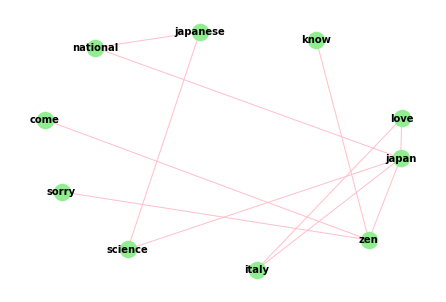

<Figure size 2e+06x2e+06 with 0 Axes>

In [20]:
nx.draw(YT_jp_nw, pos = nx.spring_layout(YT_jp_nw, k=5),
    node_color='lightgreen', linewidths=0.125, font_size=10,
    font_weight='bold', edge_color= 'pink', with_labels=True)

plt.figure(num=None, figsize=(2000, 2000), dpi=1000)


plt.show()

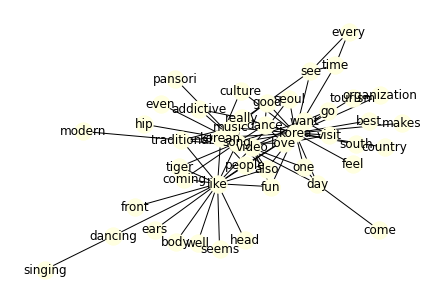

In [311]:
nx.draw(YT_kr_nw, node_color='lightyellow', with_labels = True)

In [35]:
YT_sw_nw = nx.Graph()

YT_sw_nw = nx.nx.from_pandas_edgelist(clean_data, source = 'clean_data', target = 'clean_data')
print(nx.info(YT_sw_nw))

plt.figure(figsize=(20, 20))
pos = nx.spring_layout(g, k = 0.15)
nx.draw_networkx(g,pos, node_size = 25, node_color = 'blue')
plt.show()

AttributeError: module networkx has no attribute nx